# Análisis Exploratorio de los Datos

### Importación de librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

ruta_csv = Path("../../data_index.csv")
ruta_metadatos = Path("../../metadata")

### Lectura del CSV

In [5]:
df_csv = pd.read_csv(ruta_csv)
df_csv['Subject'] = df_csv['Subject'].astype(str).str.strip()

df_clinico = df_csv.drop_duplicates(subset=['Subject']).copy()
df_clinico['Age'] = pd.to_numeric(df_clinico['Age'], errors='coerce')
df_clinico.head()

,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I1473172,100001,PD,M,67,BL,MRI,SAG 3D MPRAGE,Original,10/07/2020,DCM,NaN
1,I1473678,100017,PD,F,59,BL,MRI,SAG 3D MPRAGE,Original,12/22/2020,DCM,NaN
2,I1473204,100738,PD,F,71,BL,MRI,SAG FSPGR 3D VOLUMETRIC T1,Original,2/19/2021,DCM,NaN
3,I1493035,100878,PD,M,66,BL,MRI,3D T1-weighted,Original,3/23/2021,DCM,NaN
4,I1622593,100889,PD,F,75,BL,MRI,3D T1-weighted,Original,3/16/2021,DCM,NaN


### Lectura de los XML y mapeado con el CSV

In [6]:
datos_xml = []

for ruta_xml in ruta_metadatos.glob("*.xml"):
    try:
        arbol = ET.parse(ruta_xml)
        raiz = arbol.getroot()
        
        nodo_sujeto = raiz.find(".//subjectIdentifier")
        id_sujeto = nodo_sujeto.text.strip() if nodo_sujeto is not None else None
        
        info_paciente = {'Subject': id_sujeto}
        
        for protocolo in raiz.findall(".//protocol"):
            termino = protocolo.get("term")
            if termino in ["Manufacturer", "Field Strength", "Matrix X", "Matrix Y", "Matrix Z", "Slice Thickness"]:
                info_paciente[termino] = protocolo.text.strip()
                
        datos_xml.append(info_paciente)
    except:
        pass

df_tecnico = pd.DataFrame(datos_xml)
df_tecnico = df_tecnico.drop_duplicates(subset=['Subject'])

df_maestro = pd.merge(df_clinico, df_tecnico, on='Subject', how='inner')

for columna in ["Matrix X", "Matrix Y", "Matrix Z", "Field Strength"]:
    if columna in df_maestro.columns:
        df_maestro[columna] = pd.to_numeric(df_maestro[columna], errors='coerce')


df_maestro.head()

,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded,Slice Thickness,Matrix X,Matrix Y,Matrix Z,Manufacturer,Field Strength
0,I1473172,100001,PD,M,67,BL,MRI,SAG 3D MPRAGE,Original,10/07/2020,DCM,NaN,1.0,256.0,256.0,192.0,SIEMENS,3.0
1,I1473678,100017,PD,F,59,BL,MRI,SAG 3D MPRAGE,Original,12/22/2020,DCM,NaN,1.0,256.0,256.0,192.0,SIEMENS,3.0
2,I1473204,100738,PD,F,71,BL,MRI,SAG FSPGR 3D VOLUMETRIC T1,Original,2/19/2021,DCM,NaN,1.0,256.0,256.0,188.0,GE MEDICAL SYSTEMS,3.0
3,I1493035,100878,PD,M,66,BL,MRI,3D T1-weighted,Original,3/23/2021,DCM,NaN,1.0,256.0,256.0,192.0,Philips Medical Systems,3.0
4,I1622593,100889,PD,F,75,BL,MRI,3D T1-weighted,Original,3/16/2021,DCM,NaN,1.0,256.0,256.0,192.0,Philips Medical Systems,3.0


### Balanceo de datos

#### Clases

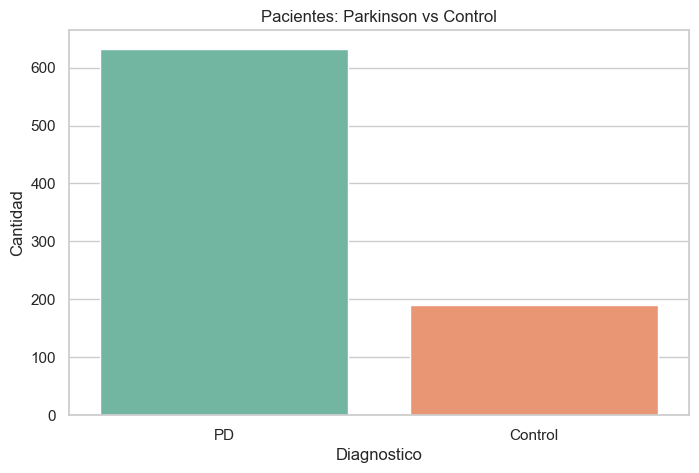

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_maestro, x='Group', hue='Group', palette='Set2', legend=False)
plt.title('Pacientes: Parkinson vs Control')
plt.xlabel('Diagnostico')
plt.ylabel('Cantidad')
plt.show()

#### Rango edades

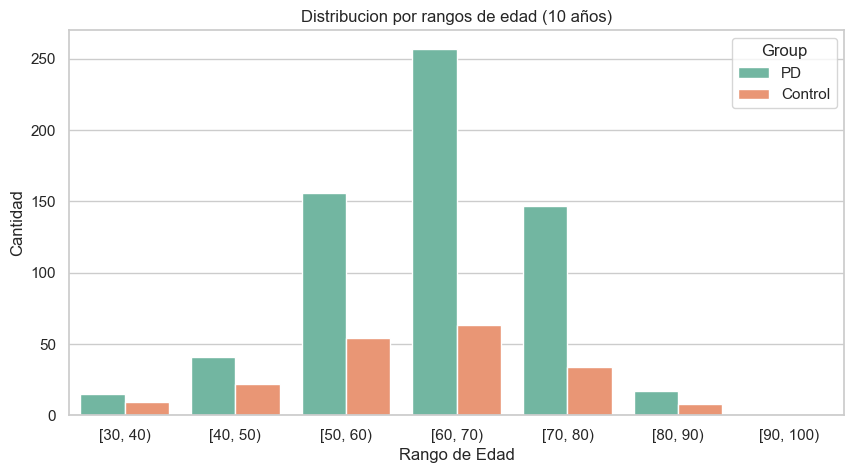

In [8]:
df_maestro['Rango_Edad'] = pd.cut(df_maestro['Age'], bins=range(30, 101, 10), right=False)

plt.figure(figsize=(10, 5))
sns.countplot(data=df_maestro, x='Rango_Edad', hue='Group', palette='Set2')
plt.title('Distribucion por rangos de edad (10 años)')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad')
plt.show()

#### Sexos

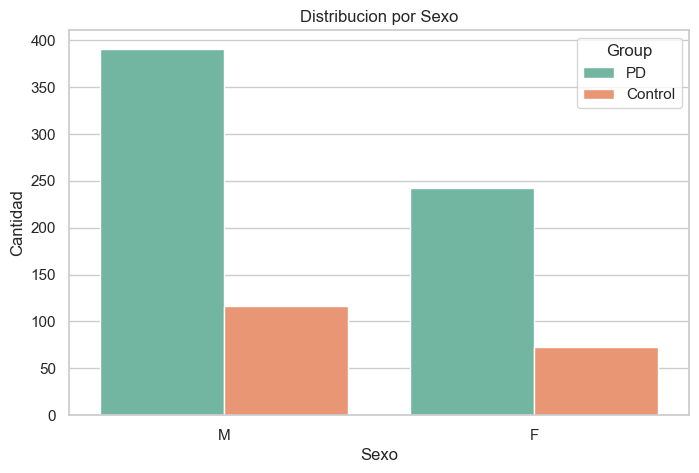

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_maestro, x='Sex', hue='Group', palette='Set2')
plt.title('Distribucion por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')
plt.show()

#### Fabricante del escáner

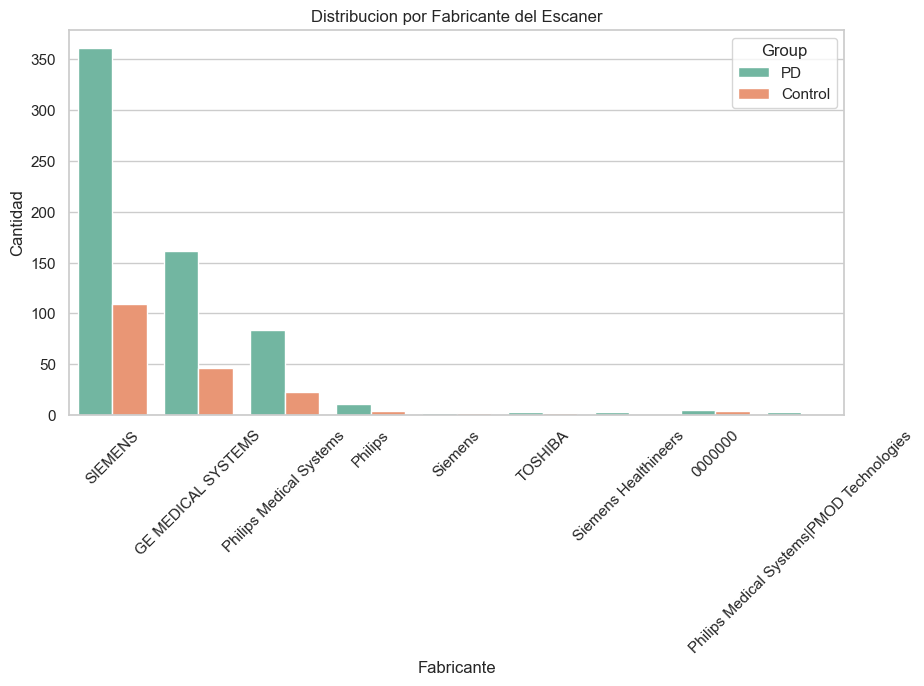

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_maestro, x='Manufacturer', hue='Group', palette='Set2')
plt.title('Distribucion por Fabricante del Escaner')
plt.xlabel('Fabricante')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()